In [1]:
import pandas as pd
df=pd.read_csv('C:/Users/.../SIGIR_regression.csv')
df

,Unnamed: 0,ID,url,Output_Gemini,Output_AIO,Output_SERP,dataset,SERP_empty,AIO_empty,Gemini_empty,...,Spam,Sports,Technology,Travel,Vehicles,Violence,Weather,Bias,Reporting,Credibility
0,0,1,https://accesscarepartners.org/a-world-of-cele...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,https://artsandculture.google.com/story/8-fest...,1,0,0,Amazon Retail,False,False,False,...,0,0,1,0,0,0,0,NaN,NaN,NaN
2,2,1,https://en.wikipedia.org/wiki/Christmas_tradit...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,Least Biased,Mixed,Medium Credibility
3,3,1,https://forsythfamilymagazine.com/discovering-...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,4,1,https://goodmenproject.com/featured-content/10...,1,0,1,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,Left,High,High Credibility
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165929,165929,11500,https://www.developmentaid.org/news-stream/pos...,0,1,0,ORCAS,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
165930,165930,11500,https://www.epa.gov/environmental-topics,0,0,1,ORCAS,False,False,False,...,0,0,0,0,0,0,0,Right,Mixed,Medium Credibility
165931,165931,11500,https://www.ibm.com/think/topics/environmental...,1,0,1,ORCAS,False,False,False,...,0,0,1,0,0,0,0,NaN,NaN,NaN
165932,165932,11500,https://www.nrep.org/blog/environmental-sustai...,1,0,0,ORCAS,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [2]:
different_categories=df.groupby('ID').mean('Ads')[['Ads', 'Adult Themes',
       'Business & Economy', 'CIPA Filter', 'Deceptive Ads', 'Drugs',
       'Education', 'Entertainment', 'Gambling', 'Government & Non-profits',
       'Hacking', 'Health', 'Internet Communication', 'Job Search & Careers',
       'Login Screens', 'Military & Weapons', 'Miscellaneous',
       'Newly Seen Domains', 'No Content', 'Potentially Malicious',
       'Questionable Content', 'Real Estate', 'Religion', 'Safe for Kids',
       'Scam', 'School Cheating', 'Security threats', 'Shopping & Auctions',
       'Society & Lifestyle', 'Spam', 'Sports', 'Technology', 'Travel',
       'Vehicles', 'Violence', 'Weather']]
different_categories
((different_categories > 0) & (different_categories < 1)).mean() * 100,((different_categories > 0)).mean() * 100

(Ads                          0.483936
 Adult Themes                 0.483936
 Business & Economy          61.043151
 CIPA Filter                  7.648878
 Deceptive Ads                0.013443
 Drugs                        0.389837
 Education                   85.226509
 Entertainment               86.463234
 Gambling                     1.129184
 Government & Non-profits    57.507730
 Hacking                      0.013443
 Health                      35.018148
 Internet Communication      67.388090
 Job Search & Careers         9.947574
 Login Screens                1.976072
 Military & Weapons           3.078371
 Miscellaneous                0.147869
 Newly Seen Domains           0.053771
 No Content                   0.134427
 Potentially Malicious        0.268853
 Questionable Content         0.295739
 Real Estate                  6.143299
 Religion                     3.804275
 Safe for Kids                2.043285
 Scam                         0.013443
 School Cheating         

In [3]:
df[df["CIPA Filter"]==1]['domain']
cipa_rows = df[df['CIPA Filter'] == 1]
cooccurrence_counts = cipa_rows[['Ads', 'Adult Themes',
       'Business & Economy', 'Deceptive Ads', 'Drugs',
       'Education', 'Entertainment', 'Gambling', 'Government & Non-profits',
       'Hacking', 'Health', 'Internet Communication', 'Job Search & Careers',
       'Login Screens', 'Military & Weapons', 'Miscellaneous',
       'Newly Seen Domains', 'No Content', 'Potentially Malicious',
       'Questionable Content', 'Real Estate', 'Religion', 'Safe for Kids',
       'Scam', 'School Cheating', 'Security threats', 'Shopping & Auctions',
       'Society & Lifestyle', 'Spam', 'Sports', 'Technology', 'Travel',
       'Vehicles', 'Violence', 'Weather']].sum()
cooccurrence_counts.sort_values(ascending=False)

School Cheating             299
Military & Weapons          274
Shopping & Auctions         248
Society & Lifestyle         193
Gambling                    122
Technology                  116
Drugs                       103
Education                    88
Government & Non-profits     74
Internet Communication       62
Entertainment                60
Health                       54
Security threats             44
Adult Themes                 44
Travel                       31
Questionable Content         26
Sports                       25
Business & Economy           22
Violence                      5
Real Estate                   4
Newly Seen Domains            2
Potentially Malicious         1
Spam                          1
Scam                          1
Job Search & Careers          1
Hacking                       1
Vehicles                      0
Ads                           0
No Content                    0
Safe for Kids                 0
Religion                      0
Miscella

In [4]:
for i in ['Ads', 'Adult Themes',
       'Business & Economy', 'Deceptive Ads', 'Drugs',
       'Education', 'Entertainment', 'Gambling', 'Government & Non-profits',
       'Hacking', 'Health', 'Internet Communication', 'Job Search & Careers',
       'Login Screens', 'Military & Weapons', 'Miscellaneous',
       'Newly Seen Domains', 'No Content', 'Potentially Malicious',
       'Questionable Content', 'Real Estate', 'Religion', 'Safe for Kids',
       'Scam', 'School Cheating', 'Security threats', 'Shopping & Auctions',
       'Society & Lifestyle', 'Spam', 'Sports', 'Technology', 'Travel',
       'Vehicles', 'Violence', 'Weather']: 
    subset=df[df[i]==1]
    subset2=subset[subset['CIPA Filter']==1]
    print(i,len(subset2)/len(subset))

##So CIPA Filter covers for Adult Themes, Drugs, Gambling, Hacking, Questionable Content, Scams,School cheating,Spam, or Violence. 

Ads 0.0
Adult Themes 1.0
Business & Economy 0.0010300107682943958
Deceptive Ads 0.0
Drugs 1.0
Education 0.0021321445012477892
Entertainment 0.0019771311826539692
Gambling 1.0
Government & Non-profits 0.0029654564398493228
Hacking 1.0
Health 0.002552346741031337
Internet Communication 0.0037992524051718856
Job Search & Careers 0.000664451827242525
Login Screens 0.0
Military & Weapons 0.4287949921752739
Miscellaneous 0.0
Newly Seen Domains 0.4
No Content 0.0
Potentially Malicious 0.047619047619047616
Questionable Content 1.0
Real Estate 0.0038461538461538464
Religion 0.0
Safe for Kids 0.0
Scam 1.0
School Cheating 1.0
Security threats 0.7586206896551724
Shopping & Auctions 0.013503947726653961
Society & Lifestyle 0.01099840437656713
Spam 1.0
Sports 0.011327594019030359
Technology 0.008060033351862146
Travel 0.007936507936507936
Vehicles 0.0
Violence 1.0
Weather 0.0


In [5]:
import tldextract
def extract_suffix(row):
    ext = tldextract.extract(row['url'])
    return f"{ext.suffix}" if ext.suffix else None
df["suffix"] = df.apply(extract_suffix, axis=1).str.lower()
df

,Unnamed: 0,ID,url,Output_Gemini,Output_AIO,Output_SERP,dataset,SERP_empty,AIO_empty,Gemini_empty,...,Spam,Sports,Technology,Travel,Vehicles,Violence,Weather,Bias,Reporting,Credibility
0,0,1,https://accesscarepartners.org/a-world-of-cele...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,https://artsandculture.google.com/story/8-fest...,1,0,0,Amazon Retail,False,False,False,...,0,0,1,0,0,0,0,NaN,NaN,NaN
2,2,1,https://en.wikipedia.org/wiki/Christmas_tradit...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,Least Biased,Mixed,Medium Credibility
3,3,1,https://forsythfamilymagazine.com/discovering-...,1,0,0,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,4,1,https://goodmenproject.com/featured-content/10...,1,0,1,Amazon Retail,False,False,False,...,0,0,0,0,0,0,0,Left,High,High Credibility
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165929,165929,11500,https://www.developmentaid.org/news-stream/pos...,0,1,0,ORCAS,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN
165930,165930,11500,https://www.epa.gov/environmental-topics,0,0,1,ORCAS,False,False,False,...,0,0,0,0,0,0,0,Right,Mixed,Medium Credibility
165931,165931,11500,https://www.ibm.com/think/topics/environmental...,1,0,1,ORCAS,False,False,False,...,0,0,1,0,0,0,0,NaN,NaN,NaN
165932,165932,11500,https://www.nrep.org/blog/environmental-sustai...,1,0,0,ORCAS,False,False,False,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [6]:
df['tranco_rank'] = df['tranco_rank'].fillna(1000001)
df = pd.get_dummies(
    df,
    columns=['Bias','Credibility','Reporting'],
    #dummy_na=True,
    drop_first=False
)
cols_with_na = df.columns[df.isna().any()].tolist()
cols_with_na


['sub_domain', 'domain_clean_x', 'suffix']

In [7]:
df['ranked']=df['tranco_rank']<1000001

In [8]:
import numpy as np
bins = [0, 100, 1000, 10000, 100000, 1000000, np.inf]
labels = ['1-100', '100-1k', '1k-10k', '10k-100k', '100k-1M', '1M+']

# 2. Create the categorical column
df['rank_group'] = pd.cut(df['tranco_rank'], bins=bins, labels=labels)

# 3. Create dummy variables
# drop_first=True is recommended for regression to avoid the Dummy Variable Trap
rank_dummies = pd.get_dummies(df['rank_group'], prefix='rank', drop_first=False)

# 4. Concatenate back to original dataframe
df = pd.concat([df, rank_dummies], axis=1)
df.columns

Index(['Unnamed: 0', 'ID', 'url', 'Output_Gemini', 'Output_AIO', 'Output_SERP',
       'dataset', 'SERP_empty', 'AIO_empty', 'Gemini_empty', 'list_pos',
       'sub_domain', 'domain_clean_x', 'suffix', 'http_scheme', 'domain',
       'categories', 'high_level_categories', 'tranco_rank', 'unranked',
       'google_extended', 'cloud_vertex_bot', 'Ads', 'Adult Themes',
       'Business & Economy', 'CIPA Filter', 'Deceptive Ads', 'Drugs',
       'Education', 'Entertainment', 'Gambling', 'Government & Non-profits',
       'Hacking', 'Health', 'Internet Communication', 'Job Search & Careers',
       'Login Screens', 'Military & Weapons', 'Miscellaneous',
       'Newly Seen Domains', 'No Content', 'Potentially Malicious',
       'Questionable Content', 'Real Estate', 'Religion', 'Safe for Kids',
       'Scam', 'School Cheating', 'Security threats', 'Shopping & Auctions',
       'Society & Lifestyle', 'Spam', 'Sports', 'Technology', 'Travel',
       'Vehicles', 'Violence', 'Weather', 'Bias_Con

In [9]:
df = df.rename(columns=lambda c: c.replace(" ", "_"))
df = df.rename(columns=lambda c: c.replace("&", "a"))
df = df.rename(columns=lambda c: c.replace("+", "plus"))
df = df.rename(columns=lambda c: c.replace("-", "_"))
df.columns

Index(['Unnamed:_0', 'ID', 'url', 'Output_Gemini', 'Output_AIO', 'Output_SERP',
       'dataset', 'SERP_empty', 'AIO_empty', 'Gemini_empty', 'list_pos',
       'sub_domain', 'domain_clean_x', 'suffix', 'http_scheme', 'domain',
       'categories', 'high_level_categories', 'tranco_rank', 'unranked',
       'google_extended', 'cloud_vertex_bot', 'Ads', 'Adult_Themes',
       'Business_a_Economy', 'CIPA_Filter', 'Deceptive_Ads', 'Drugs',
       'Education', 'Entertainment', 'Gambling', 'Government_a_Non_profits',
       'Hacking', 'Health', 'Internet_Communication', 'Job_Search_a_Careers',
       'Login_Screens', 'Military_a_Weapons', 'Miscellaneous',
       'Newly_Seen_Domains', 'No_Content', 'Potentially_Malicious',
       'Questionable_Content', 'Real_Estate', 'Religion', 'Safe_for_Kids',
       'Scam', 'School_Cheating', 'Security_threats', 'Shopping_a_Auctions',
       'Society_a_Lifestyle', 'Spam', 'Sports', 'Technology', 'Travel',
       'Vehicles', 'Violence', 'Weather', 'Bias_Con

In [11]:
len(set(df.suffix))
from collections import Counter
Counter(df.suffix)

Counter({'com': 107435,
         'org': 27553,
         'gov': 9024,
         'edu': 5932,
         'co.uk': 1987,
         'net': 1883,
         'ca': 1014,
         'com.au': 810,
         'org.uk': 641,
         'in': 494,
         'co': 485,
         'eu': 401,
         'io': 391,
         'nhs.uk': 383,
         'ac.uk': 360,
         'ai': 292,
         'me': 289,
         'us': 283,
         'gov.au': 243,
         'info': 228,
         'gov.uk': 219,
         'es': 215,
         'mil': 214,
         'int': 208,
         'de': 172,
         'org.au': 154,
         'ie': 137,
         'edu.au': 125,
         'gov.in': 113,
         'cn': 110,
         'app': 110,
         'uk': 102,
         'pub': 97,
         'co.za': 91,
         'com.cn': 91,
         'vic.gov.au': 85,
         'ch': 83,
         'co.nz': 83,
         'gov.cn': 77,
         'nl': 73,
         'fr': 73,
         'scot': 69,
         'ac.in': 64,
         'tv': 61,
         'net.au': 57,
         'org.nz': 53,


In [12]:
import pandas as pd
import numpy as np

allowed_suffixes = {'com', 'edu', 'gov', 'org'}
df['suffix_clean'] = np.where(
    df['suffix'].isin(allowed_suffixes), 
    df['suffix'], 
    'other'
)


suffix_dummies = pd.get_dummies(df['suffix_clean'], prefix='suffix')


suffix_dummies = suffix_dummies.drop('suffix_other', axis=1)


df = pd.concat([df, suffix_dummies], axis=1)
df

,Unnamed:_0,ID,url,Output_Gemini,Output_AIO,Output_SERP,dataset,SERP_empty,AIO_empty,Gemini_empty,...,rank_100_1k,rank_1k_10k,rank_10k_100k,rank_100k_1M,rank_1Mplus,suffix_clean,suffix_com,suffix_edu,suffix_gov,suffix_org
0,0,1,https://accesscarepartners.org/a-world-of-cele...,1,0,0,Amazon Retail,False,False,False,...,False,False,False,False,True,org,False,False,False,True
1,1,1,https://artsandculture.google.com/story/8-fest...,1,0,0,Amazon Retail,False,False,False,...,False,False,False,False,False,com,True,False,False,False
2,2,1,https://en.wikipedia.org/wiki/Christmas_tradit...,1,0,0,Amazon Retail,False,False,False,...,False,False,False,False,False,org,False,False,False,True
3,3,1,https://forsythfamilymagazine.com/discovering-...,1,0,0,Amazon Retail,False,False,False,...,False,False,False,False,True,com,True,False,False,False
4,4,1,https://goodmenproject.com/featured-content/10...,1,0,1,Amazon Retail,False,False,False,...,False,False,True,False,False,com,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165929,165929,11500,https://www.developmentaid.org/news-stream/pos...,0,1,0,ORCAS,False,False,False,...,False,False,False,True,False,org,False,False,False,True
165930,165930,11500,https://www.epa.gov/environmental-topics,0,0,1,ORCAS,False,False,False,...,True,False,False,False,False,gov,False,False,True,False
165931,165931,11500,https://www.ibm.com/think/topics/environmental...,1,0,1,ORCAS,False,False,False,...,True,False,False,False,False,com,True,False,False,False
165932,165932,11500,https://www.nrep.org/blog/environmental-sustai...,1,0,0,ORCAS,False,False,False,...,False,False,False,False,True,org,False,False,False,True


In [13]:
df = pd.get_dummies(
    df,
    columns=['google_extended','cloud_vertex_bot'],
    #dummy_na=True,
    drop_first=False
)
df = df.rename(columns=lambda c: c.replace(" ", "_"))
df.columns

Index(['Unnamed:_0', 'ID', 'url', 'Output_Gemini', 'Output_AIO', 'Output_SERP',
       'dataset', 'SERP_empty', 'AIO_empty', 'Gemini_empty', 'list_pos',
       'sub_domain', 'domain_clean_x', 'suffix', 'http_scheme', 'domain',
       'categories', 'high_level_categories', 'tranco_rank', 'unranked', 'Ads',
       'Adult_Themes', 'Business_a_Economy', 'CIPA_Filter', 'Deceptive_Ads',
       'Drugs', 'Education', 'Entertainment', 'Gambling',
       'Government_a_Non_profits', 'Hacking', 'Health',
       'Internet_Communication', 'Job_Search_a_Careers', 'Login_Screens',
       'Military_a_Weapons', 'Miscellaneous', 'Newly_Seen_Domains',
       'No_Content', 'Potentially_Malicious', 'Questionable_Content',
       'Real_Estate', 'Religion', 'Safe_for_Kids', 'Scam', 'School_Cheating',
       'Security_threats', 'Shopping_a_Auctions', 'Society_a_Lifestyle',
       'Spam', 'Sports', 'Technology', 'Travel', 'Vehicles', 'Violence',
       'Weather', 'Bias_Conspiracy_Pseudoscience', 'Bias_Least_Bia

In [14]:
df[['cloud_vertex_bot_1', 'google_extended_1']].corr()

,cloud_vertex_bot_1,google_extended_1
cloud_vertex_bot_1,1.00000,0.75593
google_extended_1,0.75593,1.00000


In [89]:
corr_matrix=df[['tranco_rank', 'unranked', 'Ads',
       'Adult_Themes', 'Business_a_Economy', 'CIPA_Filter', 'Deceptive_Ads',
       'Drugs', 'Education', 'Entertainment', 'Gambling',
       'Government_a_Non_profits', 'Hacking', 'Health',
       'Internet_Communication', 'Job_Search_a_Careers', 'Login_Screens',
       'Military_a_Weapons', 'Miscellaneous', 'Newly_Seen_Domains',
       'No_Content', 'Potentially_Malicious', 'Questionable_Content',
       'Real_Estate', 'Religion', 'Safe_for_Kids', 'Scam', 'School_Cheating',
       'Security_threats', 'Shopping_a_Auctions', 'Society_a_Lifestyle',
        'Sports', 'Technology', 'Travel', 'Vehicles', 'Violence',
       'Weather', 'Bias_Conspiracy_Pseudoscience', 'Bias_Least_Biased',
       'Bias_Left', 'Bias_Left_Center', 'Bias_Pro_Science',
       'Bias_Questionable_Sources', 'Bias_Right', 'Bias_Right_Center',
       'Bias_Satire', 'Credibility_High_Credibility',
       'Credibility_Low_Credibility', 'Credibility_Medium_Credibility',
       'Reporting_High', 'Reporting_Low', 'Reporting_Mixed',
       'Reporting_Mostly_Factual', 'Reporting_Very_High', 'Reporting_Very_Low',
       'suffix_com', 'suffix_edu', 'suffix_gov', 'suffix_org',
       'google_extended_1', 'google_extended_Not_found', 'cloud_vertex_bot_1',
       'cloud_vertex_bot_Not_found']].corr()

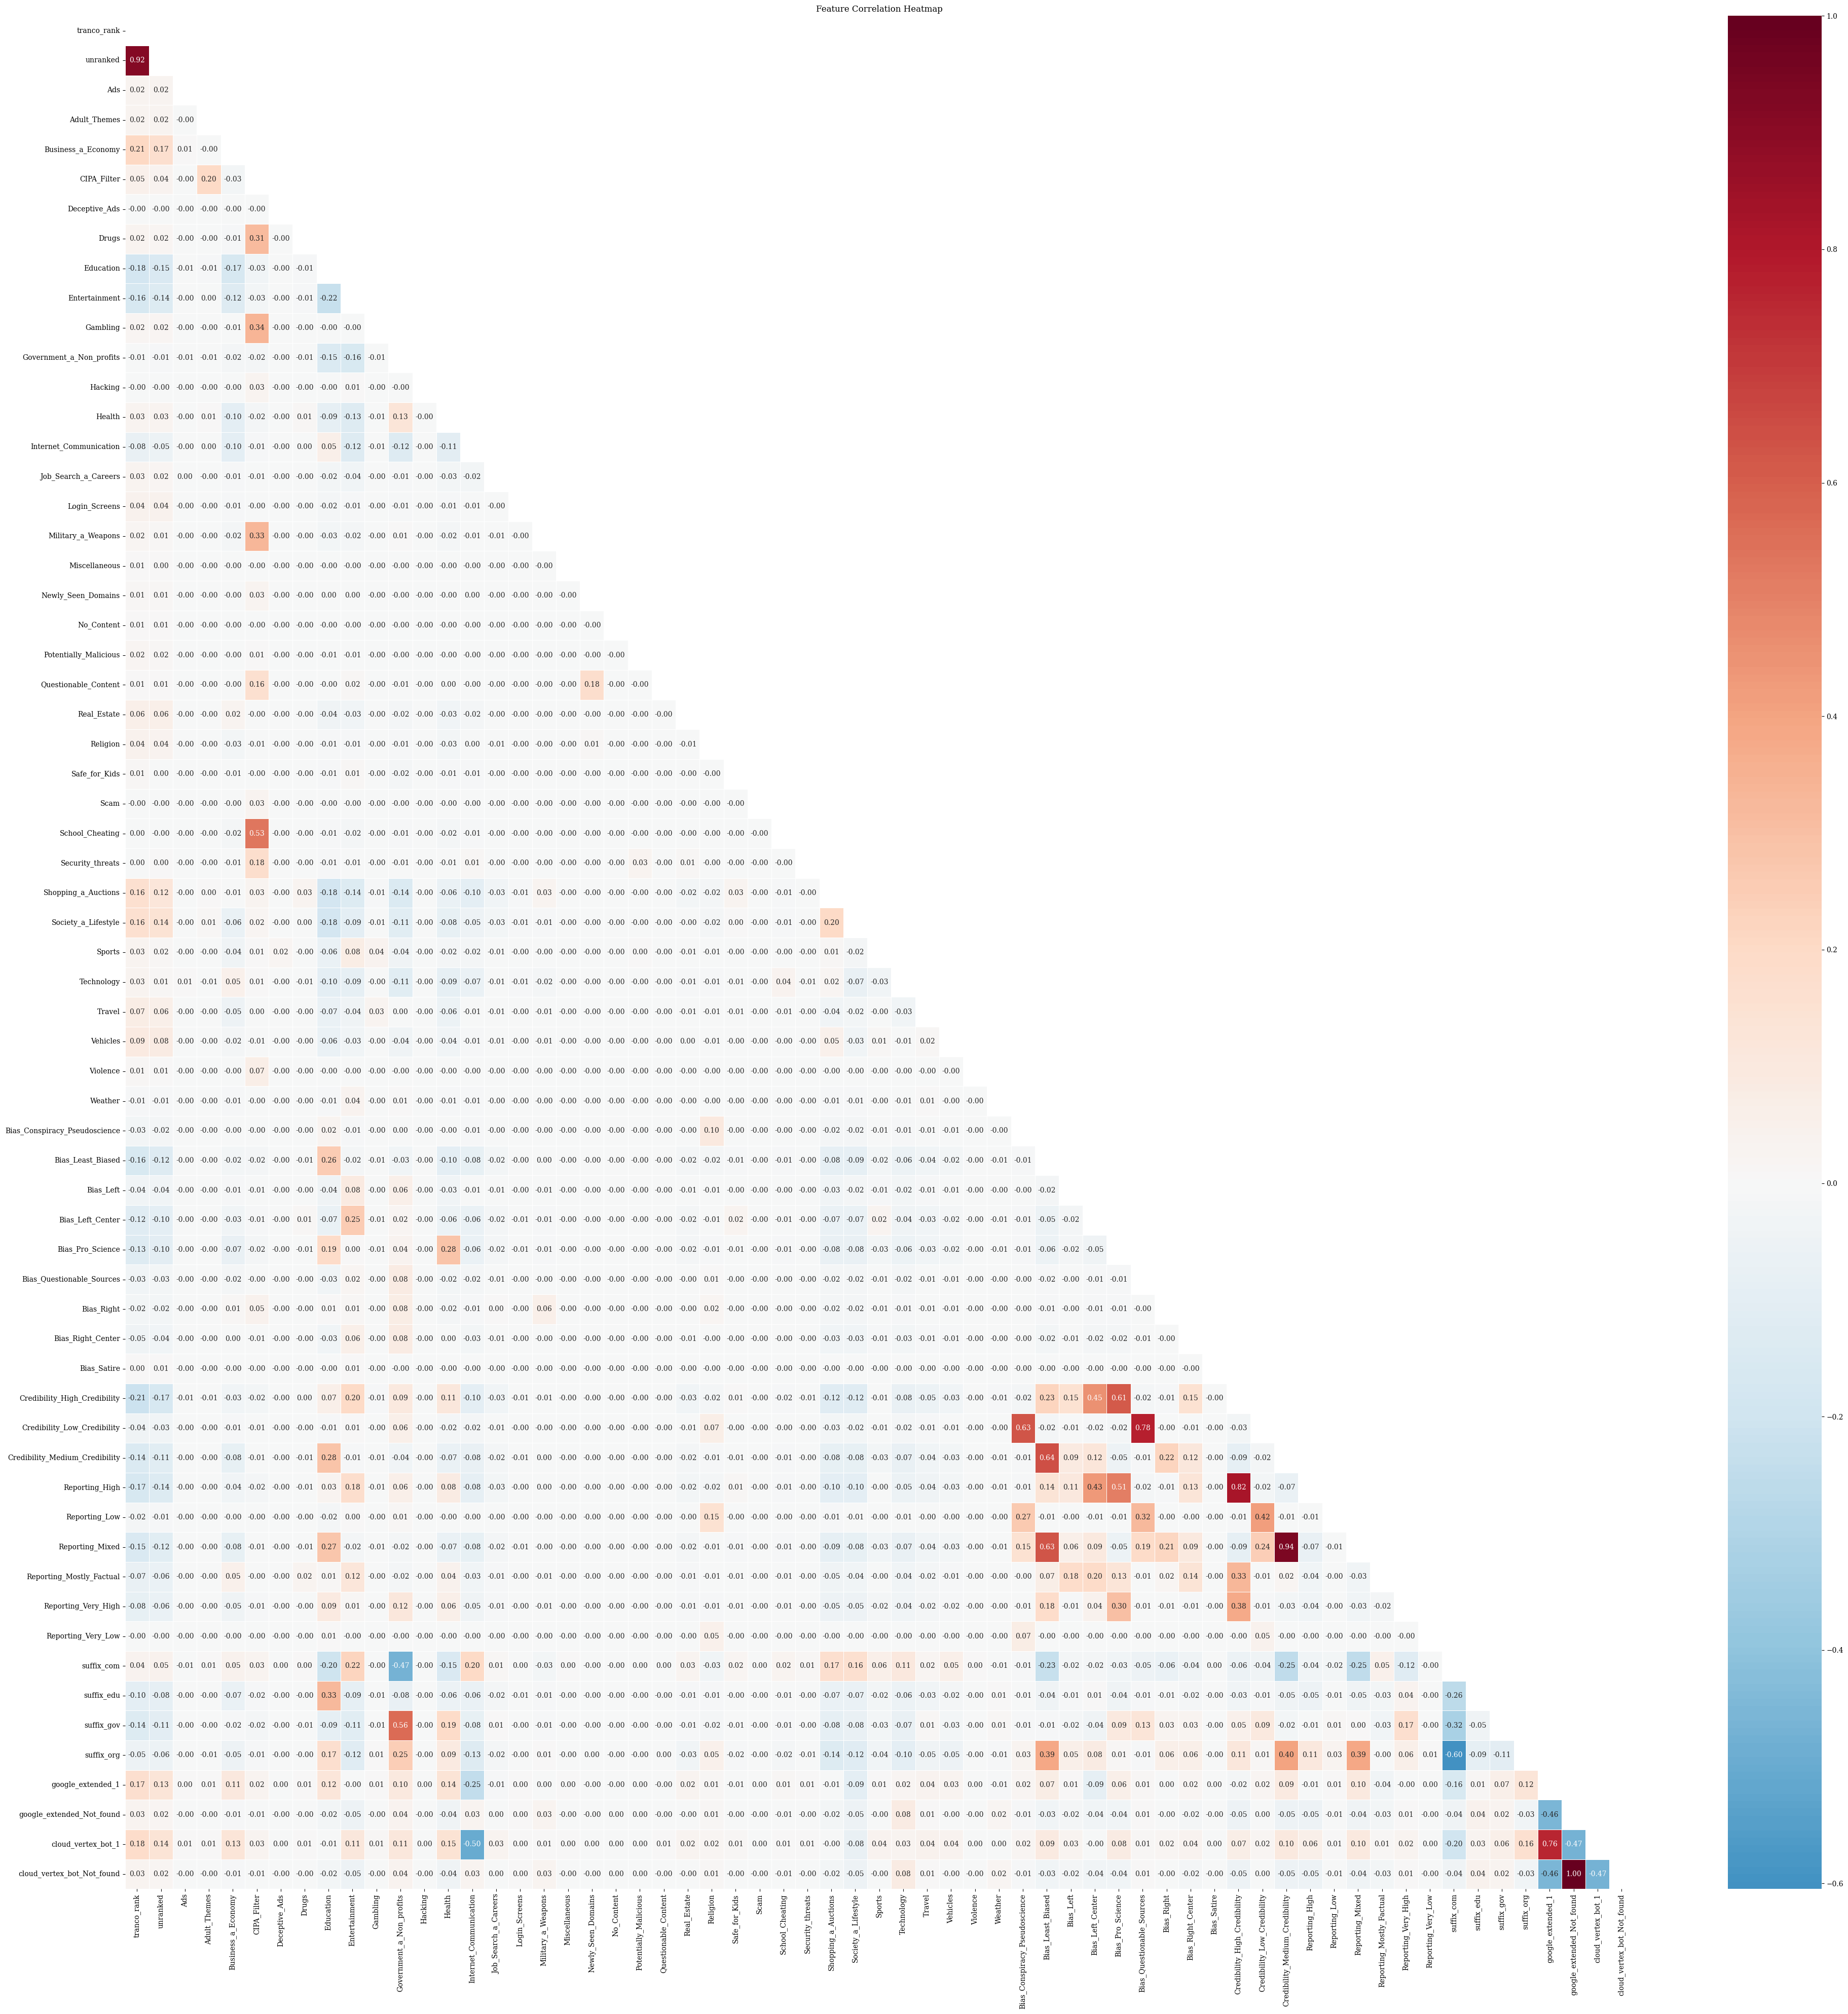

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(48, 48))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          
            fmt=".2f",          
            cmap='RdBu_r',       
            center=0, 
            linewidths=.5)

plt.title('Feature Correlation Heatmap')
plt.show()

In [91]:
df.columns

Index(['Unnamed:_0', 'ID', 'url', 'Output_Gemini', 'Output_AIO', 'Output_SERP',
       'dataset', 'SERP_empty', 'AIO_empty', 'Gemini_empty', 'list_pos',
       'sub_domain', 'domain_clean_x', 'suffix', 'http_scheme', 'domain',
       'categories', 'high_level_categories', 'tranco_rank', 'unranked', 'Ads',
       'Adult_Themes', 'Business_a_Economy', 'CIPA_Filter', 'Deceptive_Ads',
       'Drugs', 'Education', 'Entertainment', 'Gambling',
       'Government_a_Non_profits', 'Hacking', 'Health',
       'Internet_Communication', 'Job_Search_a_Careers', 'Login_Screens',
       'Military_a_Weapons', 'Miscellaneous', 'Newly_Seen_Domains',
       'No_Content', 'Potentially_Malicious', 'Questionable_Content',
       'Real_Estate', 'Religion', 'Safe_for_Kids', 'Scam', 'School_Cheating',
       'Security_threats', 'Shopping_a_Auctions', 'Society_a_Lifestyle',
       'Spam', 'Sports', 'Technology', 'Travel', 'Vehicles', 'Violence',
       'Weather', 'Bias_Conspiracy_Pseudoscience', 'Bias_Least_Bia

In [15]:
import pandas as pd




id_cols = ['ID', 'url', 'dataset', 
       'sub_domain', 'domain_clean_x', 'suffix', 'http_scheme', 'domain',
       'categories', 'high_level_categories', 'tranco_rank', 'unranked', 'Ads',
       'Adult_Themes', 'Business_a_Economy', 'CIPA_Filter', 'Deceptive_Ads',
       'Drugs', 'Education', 'Entertainment', 'Gambling',
       'Government_a_Non_profits', 'Hacking', 'Health',
       'Internet_Communication', 'Job_Search_a_Careers', 'Login_Screens',
       'Military_a_Weapons', 'Miscellaneous', 'Newly_Seen_Domains',
       'No_Content', 'Potentially_Malicious', 'Questionable_Content',
       'Real_Estate', 'Religion', 'Safe_for_Kids', 'Scam', 'School_Cheating',
       'Security_threats', 'Shopping_a_Auctions', 'Society_a_Lifestyle',
       'Spam', 'Sports', 'Technology', 'Travel', 'Vehicles', 'Violence',
       'Weather', 'Bias_Conspiracy_Pseudoscience', 'Bias_Least_Biased',
       'Bias_Left', 'Bias_Left_Center', 'Bias_Pro_Science',
       'Bias_Questionable_Sources', 'Bias_Right', 'Bias_Right_Center',
       'Bias_Satire', 'Credibility_High_Credibility',
       'Credibility_Low_Credibility', 'Credibility_Medium_Credibility',
       'Reporting_High', 'Reporting_Low', 'Reporting_Mixed',
       'Reporting_Mostly_Factual', 'Reporting_Very_High', 'Reporting_Very_Low',
       'ranked', 'rank_group', 'rank_1_100', 'rank_100_1k', 'rank_1k_10k',
       'rank_10k_100k', 'rank_100k_1M', 'rank_1Mplus', 'suffix_clean',
       'suffix_com', 'suffix_edu', 'suffix_gov', 'suffix_org',
       'google_extended_0', 'google_extended_1', 'google_extended_Not_found',
       'cloud_vertex_bot_0', 'cloud_vertex_bot_1',
       'cloud_vertex_bot_Not_found']


df_long = pd.melt(
    df,
    id_vars=id_cols,
    value_vars=['Output_Gemini', 'Output_AIO', 'Output_SERP'],
    var_name='Output_Type',
    value_name='Is_Cited'
)


df_long['Output_Type'] = df_long['Output_Type'].str.replace('Output_', '')
df_long['Output_Type'] = pd.Categorical(
    df_long['Output_Type'], 
    categories=['SERP', 'Gemini', 'AIO'], 
    ordered=True
)
df_long

,ID,url,dataset,sub_domain,domain_clean_x,suffix,http_scheme,domain,categories,high_level_categories,...,suffix_gov,suffix_org,google_extended_0,google_extended_1,google_extended_Not_found,cloud_vertex_bot_0,cloud_vertex_bot_1,cloud_vertex_bot_Not_found,Output_Type,Is_Cited
0,1,https://accesscarepartners.org/a-world-of-cele...,Amazon Retail,NaN,NaN,org,https,accesscarepartners.org,"['Business', 'Parenting']","['Business & Economy', 'Society & Lifestyle']",...,False,True,False,True,False,False,True,False,Gemini,1
1,1,https://artsandculture.google.com/story/8-fest...,Amazon Retail,NaN,NaN,com,https,google.com,['Search Engines'],['Technology'],...,False,False,False,True,False,False,True,False,Gemini,1
2,1,https://en.wikipedia.org/wiki/Christmas_tradit...,Amazon Retail,NaN,NaN,org,https,wikipedia.org,"['Education', 'Reference']",['Education'],...,False,True,False,True,False,False,True,False,Gemini,1
3,1,https://forsythfamilymagazine.com/discovering-...,Amazon Retail,NaN,NaN,com,https,forsythfamilymagazine.com,"['Magazines', 'Parenting']","['Entertainment', 'Society & Lifestyle']",...,False,False,False,True,False,False,True,False,Gemini,1
4,1,https://goodmenproject.com/featured-content/10...,Amazon Retail,goodmenproject.com,goodmenproject.com,com,https,goodmenproject.com,['Magazines'],['Entertainment'],...,False,False,False,True,False,False,True,False,Gemini,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497797,11500,https://www.developmentaid.org/news-stream/pos...,ORCAS,NaN,NaN,org,https,developmentaid.org,['Business'],['Business & Economy'],...,False,True,False,True,False,False,True,False,SERP,0
497798,11500,https://www.epa.gov/environmental-topics,ORCAS,NaN,NaN,gov,https,epa.gov,"['Business', 'Politics, Advocacy, and Governme...","['Business & Economy', 'Government & Non-profi...",...,True,False,False,True,False,False,True,False,SERP,1
497799,11500,https://www.ibm.com/think/topics/environmental...,ORCAS,NaN,NaN,com,https,ibm.com,['Technology'],['Technology'],...,False,False,False,True,False,False,True,False,SERP,1
497800,11500,https://www.nrep.org/blog/environmental-sustai...,ORCAS,NaN,NaN,org,https,nrep.org,['Education'],['Education'],...,False,True,False,True,False,False,True,False,SERP,0


In [17]:
from pyfixest.estimation import feols
adders=['CIPA_Filter','Business_a_Economy','Education','Entertainment','Government_a_Non_profits','Health','Internet_Communication','Job_Search_a_Careers','Real_Estate','Shopping_a_Auctions', 'Society_a_Lifestyle','Sports','Technology','Travel','Vehicles','Security_threats','Potentially_Malicious']
all_covariates = [
    'suffix_edu', 'google_extended_0', 'rank_1_100', 
    'rank_100_1k', 'rank_1k_10k', 'rank_10k_100k', 'rank_100k_1M'
] + adders


interact_part = " + ".join([f"i(Output_Type, {var}, ref='SERP')" for var in all_covariates])


formula = f"Is_Cited ~ Output_Type + {' + '.join(all_covariates)} + {interact_part} | ID"


fit = feols(formula, data=df_long, vcov={'CRV1': 'ID'})


print(fit.summary())

###

Estimation:  OLS
Dep. var.: Is_Cited, Fixed effects: ID
Inference:  CRV1
Observations:  497802

| Coefficient                                                                     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------------------------------------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Output_Type[T.Gemini]                                                           |      0.219 |        0.008 |    28.844 |      0.000 |  0.204 |   0.234 |
| Output_Type[T.AIO]                                                              |      0.048 |        0.007 |     6.821 |      0.000 |  0.034 |   0.062 |
| suffix_edu                                                                      |      0.097 |        0.007 |    13.515 |      0.000 |  0.083 |   0.111 |
| google_extended_0                                                               |      0.212 |        0.004 |    48.6

In [16]:
from pyfixest.estimation import feols
adders=['CIPA_Filter','Business_a_Economy','Education','Entertainment','Government_a_Non_profits','Health','Internet_Communication','Job_Search_a_Careers','Real_Estate','Shopping_a_Auctions', 'Society_a_Lifestyle','Sports','Technology','Travel','Vehicles','Security_threats','Potentially_Malicious','Credibility_High_Credibility','Credibility_Low_Credibility', 'Credibility_Medium_Credibility']
all_covariates = [
    'suffix_edu', 'google_extended_0', 'rank_1_100', 
    'rank_100_1k', 'rank_1k_10k', 'rank_10k_100k', 'rank_100k_1M'
] + adders


interact_part = " + ".join([f"i(Output_Type, {var}, ref='SERP')" for var in all_covariates])


formula = f"Is_Cited ~ Output_Type + {' + '.join(all_covariates)} + {interact_part} | ID"


fit = feols(formula, data=df_long, vcov={'CRV1': 'ID'})


print(fit.summary())

###

Estimation:  OLS
Dep. var.: Is_Cited, Fixed effects: ID
Inference:  CRV1
Observations:  497802

| Coefficient                                                                           |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------------------------------------------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Output_Type[T.Gemini]                                                                 |      0.218 |        0.008 |    28.726 |      0.000 |  0.203 |   0.232 |
| Output_Type[T.AIO]                                                                    |      0.052 |        0.007 |     7.334 |      0.000 |  0.038 |   0.066 |
| suffix_edu                                                                            |      0.119 |        0.007 |    16.376 |      0.000 |  0.105 |   0.133 |
| google_extended_0                                                                     |

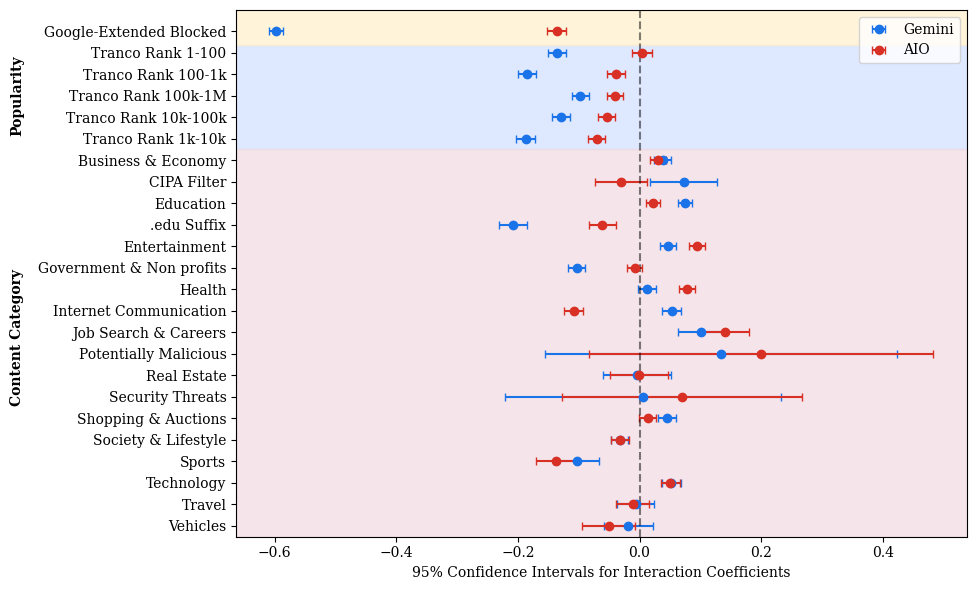

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 10         
plt.rcParams['font.weight'] = 'medium' 

summary_df = fit.tidy().reset_index()
summary_df.columns = ['term', 'estimate', 'std_err', 't_stat', 'p_val', 'ci_lower', 'ci_upper']


diff_df = summary_df[summary_df['term'].str.contains(':')].copy()


diff_df['clean_label'] = diff_df['term'].str.split(':').str[-1]
diff_df['engine'] = diff_df['term'].apply(lambda x: 'Gemini' if 'Gemini' in x else 'AIO')

diff_df = diff_df.map(lambda x: x.replace('_a_', ' & ') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('threat', 'Threat') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('_', ' ') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('suffix edu', '.edu Suffix') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('google extended 0', 'Google-Extended Blocked') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('rank', 'Tranco Rank') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('1 100', '1-100') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('100 1k', '100-1k') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('1k 10k', '1k-10k') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('10k 100k', '10k-100k') if isinstance(x, str) else x)
diff_df = diff_df.map(lambda x: x.replace('100k 1M', '100k-1M') if isinstance(x, str) else x)

desired_order = [
    'Google-Extended Blocked',
    'Tranco Rank 1-100',
 'Tranco Rank 100-1k',
 'Tranco Rank 100k-1M',
 'Tranco Rank 10k-100k',
 'Tranco Rank 1k-10k',
    'Business & Economy',
 'CIPA Filter',
 'Education',
    '.edu Suffix',
 'Entertainment',
 'Government & Non profits',
 'Health',
 'Internet Communication',
 'Job Search & Careers',
 'Potentially Malicious',
 'Real Estate',
 'Security Threats',
 'Shopping & Auctions',
 'Society & Lifestyle',
 'Sports',
 'Technology',
    'Travel',
 'Vehicles'
]

diff_df['clean_label'] = pd.Categorical(
    diff_df['clean_label'],
    categories=desired_order,
    ordered=True
)

diff_df = diff_df.sort_values('clean_label')


policy_vars = ['Google-Extended Blocked']

tranco_vars = [
    'Tranco Rank 1-100',
    'Tranco Rank 100-1k',
    'Tranco Rank 1k-10k',
    'Tranco Rank 10k-100k',
    'Tranco Rank 100k-1M'
]

diff_df['group'] = 'Content Category'
diff_df.loc[diff_df['clean_label'].isin(policy_vars), 'group'] = 'Policy'
diff_df.loc[diff_df['clean_label'].isin(tranco_vars), 'group'] = 'Popularity (Tranco)'

diff_df = diff_df.reset_index(drop=True)





fig, ax = plt.subplots(figsize=(10, 6))

ax.axhspan(
     22.35,
    17.55,
    color='#cdddff',
    alpha=0.65,
    zorder=0
    )

ax.axhspan(
     24,
    22.35,
    color='#ffefcd',
    alpha=0.75,
    zorder=0
    )
ax.axhspan(
    17.55,
    -0.5,
    color='#f2dbe2',
    alpha=0.75,
    zorder=0
    )
ax.set_ylim(-0.5,24)

for engine, color in zip(['Gemini', 'AIO'], ['#1a73e8', '#d93025']):
    sub = diff_df[diff_df['engine'] == engine]
    ax.errorbar(sub['estimate'][::-1], sub['clean_label'][::-1], 
                xerr=[sub['estimate'][::-1] - sub['ci_lower'][::-1], sub['ci_upper'][::-1] - sub['estimate'][::-1]],
                fmt='o', color=color, label=f'{engine}', capsize=3)

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('95% Confidence Intervals for Interaction Coefficients')
ax.legend(loc='upper right')


ax.text(
    -0.3, 20,
    "Popularity",
    rotation=90,
    va='center',
    ha='center',
    fontsize=10,
    fontweight='bold',
    transform=ax.get_yaxis_transform()
)

ax.text(
    -0.3, 8.75,
    "Content Category",
    rotation=90,
    va='center',
    ha='center',
    fontsize=10,
    fontweight='bold',
    transform=ax.get_yaxis_transform()
)


#plt.title('How Generative Models Shift Citation Patterns relative to SERP')
plt.tight_layout()
plt.savefig('SIGIR_regression_plotv2.pdf', format='pdf', dpi=1200)
plt.show()

In [29]:
df[(df.Output_Gemini==1) & (df.Output_AIO==1) & (df.Output_SERP==1)]

,Unnamed:_0,ID,url,Output_Gemini,Output_AIO,Output_SERP,dataset,SERP_empty,AIO_empty,Gemini_empty,...,suffix_com,suffix_edu,suffix_gov,suffix_org,google_extended_0,google_extended_1,google_extended_Not_found,cloud_vertex_bot_0,cloud_vertex_bot_1,cloud_vertex_bot_Not_found
14,14,1,https://www.cozi.com/blog/28-holiday-tradition...,1,1,1,Amazon Retail,False,False,False,...,True,False,False,False,False,True,False,False,True,False
27,27,2,https://amateurphotographer.com/buying-advice/...,1,1,1,Amazon Retail,False,False,False,...,True,False,False,False,False,True,False,False,True,False
141,141,9,https://www.ebay.com/itm/176032924535,1,1,1,Amazon Retail,False,False,False,...,True,False,False,False,False,True,False,False,True,False
253,253,42,https://www.walmart.com/c/kp/bath-body-works-g...,1,1,1,Amazon Retail,False,False,False,...,True,False,False,False,False,True,False,False,True,False
280,280,53,https://support.apple.com/en-us/105004,1,1,1,Amazon Retail,False,False,False,...,True,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165840,165840,11491,https://www.reddit.com/r/calculus/comments/wis...,1,1,1,ORCAS,False,False,False,...,True,False,False,False,True,False,False,True,False,False
165851,165851,11494,https://my.clevelandclinic.org/health/diseases...,1,1,1,ORCAS,False,False,False,...,False,False,False,True,False,True,False,False,True,False
165861,165861,11494,https://www.mayoclinic.org/diseases-conditions...,1,1,1,ORCAS,False,False,False,...,False,False,False,True,False,True,False,False,True,False
165885,165885,11495,https://www.cultureamp.com/blog/employee-feedb...,1,1,1,ORCAS,False,False,False,...,True,False,False,False,False,True,False,False,True,False
